# Ft Huachuca Biomass Data
The data was cleand and had QAQC performed in a previous notebook. This notebook picks up investigating the biomass outputs to make sure that they are reasonable and valid.

## Load Data
First, the data is loaded and cleaned following steps developed previously.

In [1]:
# import calc_biomass package
import sys
sys.path.append('../')
from calc_biomass import manage_data

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Jupyter magic to make plots display interactive
# must install ipympl (Ipython-matplotlib) and nodejs
from ipywidgets.embed import embed_minimal_html
%matplotlib widget

In [2]:
def calc_edrc(df):
    # df is one tree id from a single plot
    # for trees with only one tree id, the sqrt(d2) == d
    dbh = (sum(df['dbh']**2))**0.5
    
    other_val = df.max()

    newdf = pd.DataFrame()
    newdf.loc[1,'DBH'] = dbh
    newdf.loc[1, df.columns] = other_val

    return newdf

In [4]:
# load data
data = manage_data.LoadData()
data.load_data(data.data_path)

# calculate ERC
data.df.rename(columns={'Final DBH/DRC':'dbh', 'spp':'Species','Species Code':'spp'}, inplace=True)
data.df = data.df.groupby(['Plot', 'Tree Number']).apply(calc_edrc).reset_index()

NEW DISCOVERY!!!! The units disappeared after the GroupBy.Apply. Now we need to adjust to the altered col name as well.

In [5]:
# Error noted below, now the new df with it's new index needs to have units reassigned
data.units['input']['DBH'] = data.units['input'].pop('Final DBH/DRC')
data.check_df_units('input')

In [6]:
# clean data
pied = data.df.spp.isna() & (data.df.Species=='Pinyon')
data.df.loc[pied, 'spp'] = 'PIED'

prve = (data.df['spp']=='PRVE')&(data.df['Height']<=0)
data.df.loc[prve, 'Height'] = data.df.loc[prve, 'Base reading']/100

jude = (data.df['spp']=='JUDE2')&(data.df['Height']<0)
ht = (-data.df.loc[jude, 'Top Reading']- data.df.loc[jude, 'Base reading']) / 100 * data.df.loc[jude, 'Distance (M)']
data.df.loc[jude, 'Height'] = ht

wt = manage_data.CalcBiomass(data)
# what equations should be used for these species?
wt.add_equ_column()

In [7]:
wt.ldata.df.info()

<class 'pandas.DataFrame'>
RangeIndex: 509 entries, 0 to 508
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype               
---  ------                        --------------  -----               
 0   Plot                          509 non-null    object              
 1   Tree Number                   509 non-null    float64             
 2   level_2                       509 non-null    int64               
 3   DBH                           509 non-null    pint[inch][Float64] 
 4   Quadrant                      509 non-null    str                 
 5   Species                       509 non-null    str                 
 6   spp                           509 non-null    object              
 7   DBH/DRC calculated            509 non-null    float64             
 8   DBH/DRC                       347 non-null    object              
 9   dbh                           509 non-null    object              
 10  Unnamed: 8                    509 non

## Calculating biomass

In [48]:
wt.calc_biomass('total')

172: RuntimeWarning: invalid value encountered in log10
172: RuntimeWarning: invalid value encountered in log10


In [49]:
wt.calc_biomass('foliage')

172: RuntimeWarning: invalid value encountered in log10


In [50]:
wt.calc_biomass('avl_canfuel')

172: RuntimeWarning: invalid value encountered in log10
172: RuntimeWarning: invalid value encountered in log10


### Chojnacky producing valid values

Problems discussed previously have now been fixed.

In [11]:
eq = wt.ldata.df.equ == 'OakWoodland_Chojnacky'
wt.ldata.df.loc[eq, ['Species', 'equ', 'total_wt']]

,Species,equ,total_wt
8,Mexican Blue Oak,OakWoodland_Chojnacky,419.666496
14,Mexican Blue Oak,OakWoodland_Chojnacky,90.062109
20,AZ White Oak,OakWoodland_Chojnacky,18.066674
21,AZ White Oak,OakWoodland_Chojnacky,81.157153
23,AZ White Oak,OakWoodland_Chojnacky,34.098197
...,...,...,...
420,Mexican Blue Oak,OakWoodland_Chojnacky,100.988665
421,Mexican Blue Oak,OakWoodland_Chojnacky,101.329458
462,Mexican Blue Oak,OakWoodland_Chojnacky,628.808909
466,Net Leaf Oak,OakWoodland_Chojnacky,176.658916


Now let's figure out where we're getting this log(-number).

In [12]:
from calc_biomass import allometry

# first get a clean df with the right units and column names
df_slice = wt.ldata.df[wt.ldata.df.equ =='OakWoodland_Chojnacky']
owc_cls = getattr(allometry, 'OakWoodland_Chojnacky')
df_clean = wt.get_clean_df(df_slice, owc_cls.required_columns, owc_cls.units )

ow = allometry.OakWoodland_Chojnacky(df_clean)

In [13]:
br = ow.eq_VOLUME_branchdiam()
df_clean[br<0]

,DBH,HT,spp_eq,equ
81,4.138029,1.9995,QUERCUS,OakWoodland_Chojnacky
178,0.63662,8.25,QUEM,OakWoodland_Chojnacky


In [14]:
br[br<0]

array([-0.37253576, -1.39958503])

In [15]:
pd.options.display.max_columns = 50

In [16]:
ix = df_clean[br<0].index
wt.ldata.df.iloc[ix]

,Plot,Tree Number,level_2,DBH,Quadrant,Species,spp,DBH/DRC calculated,DBH/DRC,dbh,Unnamed: 8,DBH/DRC Circumfrence (cm),Height,Base reading,Top Reading,Crown Class,Lowest Canopy Height,Lowest Canopy Height Reading,Tree Condition,Distance (M),Stems,spp_eq,equ,total_wt,foliage_wt,avl_canfuel_wt
81,358,28.0,1,1.629145,SW,Silver Leaf Oak,QUHY,1.629145,DRC,1.6291450867674326 inch,0.0,13.0,1.9995,-55.0,-24.0,S,1.0965,-38.0,1.0,6.45,NaN,QUERCUS,OakWoodland_Chojnacky,NaN,NaN,NaN
178,826,4.0,1,0.250638,NE,Emory Oak,QUEM,0.250638,DRC,0.2506377056565281 inch,0.0,2.0,8.25,-24.0,31.0,C,1.2,-16.0,1.0,15.00,NaN,QUEM,OakWoodland_Chojnacky,NaN,NaN,NaN


In [17]:
(np.array([8.25,1.9995])*np.array([0.6366, 4.138])**2)/2000

array([0.0016717 , 0.01711876])

In [18]:
X = np.array([0.0016717 , 0.01711876])
-1.5107 + 66.42*X + 1.3694*X**2

array([-1.39966186, -0.37327066])

OK, That manually confirms that those would calculate negative volumes... The 8 m tall one has a suspiciously small DRC, so I have Zito checking the original plot sheets to make sure that it isn't an error. 0.25 inches would be hard to measure.

Zito found that the circumference of index 178 (plot 826, tree 4) was 2 m, not 2cm, so let's fix that.

In [19]:
c = 200
d = c/np.pi
d_in = d/2.54
wt.ldata.df.loc[178, 'DBH'] = d_in
wt.ldata.df.loc[178, 'DBH/DRC Circumfrence (cm)'] = 200
wt.ldata.df.loc[ix]

,Plot,Tree Number,level_2,DBH,Quadrant,Species,spp,DBH/DRC calculated,DBH/DRC,dbh,Unnamed: 8,DBH/DRC Circumfrence (cm),Height,Base reading,Top Reading,Crown Class,Lowest Canopy Height,Lowest Canopy Height Reading,Tree Condition,Distance (M),Stems,spp_eq,equ,total_wt,foliage_wt,avl_canfuel_wt
81,358,28.0,1,1.629145,SW,Silver Leaf Oak,QUHY,1.629145,DRC,1.6291450867674326 inch,0.0,13.0,1.9995,-55.0,-24.0,S,1.0965,-38.0,1.0,6.45,NaN,QUERCUS,OakWoodland_Chojnacky,NaN,NaN,NaN
178,826,4.0,1,25.063771,NE,Emory Oak,QUEM,0.250638,DRC,0.2506377056565281 inch,0.0,200.0,8.25,-24.0,31.0,C,1.2,-16.0,1.0,15.00,NaN,QUEM,OakWoodland_Chojnacky,NaN,NaN,NaN


That fixes the one error, but it leaves a tiny little 2m tree with <2" diameter. 

### Filter negative volume
Let's test a strategy for an automatic filter. It's risky to correct any negative value without any sort of check, so let's first ID a DBH and height where the value is likely to go negative.

Text(0, 0.5, 'Tree vol (liters)')

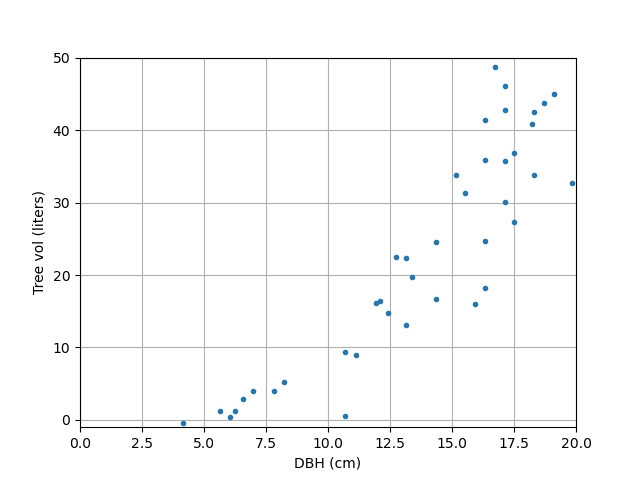

In [20]:
plt.figure()
plt.plot(df_clean['DBH'], br, linestyle='', marker='.')

plt.grid('on')
plt.xlim([0, 20])
plt.ylim([-1, 50])
plt.xlabel('DBH (cm)')
plt.ylabel('Tree vol (liters)')

Text(0, 0.5, 'Tree vol (liters)')

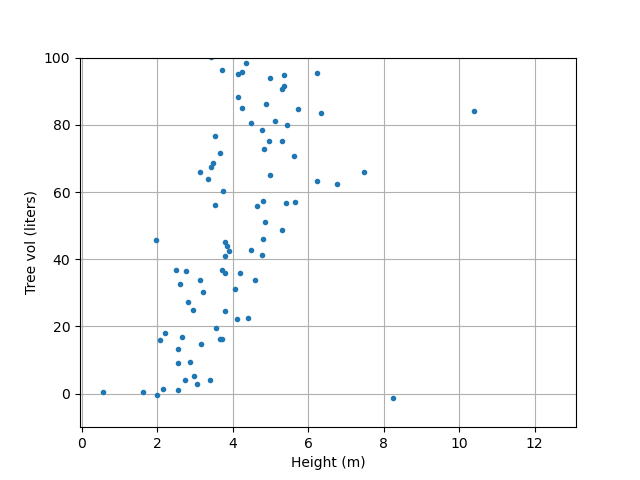

In [21]:
plt.figure()
plt.plot(df_clean['HT'], br, linestyle='', marker='.')
plt.grid('on')

plt.ylim([-10, 100])

plt.xlabel('Height (m)')
plt.ylabel('Tree vol (liters)')

The one negative value at 8m height is from that micro dbh corrected above.

So if DBH is < 7.5 cm and height is < 4 m, and the value is negative, then we can be confident that the negative vlaue is due to the limits of the euqtion and not a misentered value.

Next, for such a small tree, what would the volume of a cylinder be? Maybe we could simply replace the equation with the volume of a cylinder.

In [22]:
dbh_m = wt.ldata.df.loc[81, 'DBH'].to('m')
a = np.pi*(dbh_m/2)**2
v = a*wt.ldata.df.loc[81, 'Height']
v.to('L')

<Quantity(2.68904611, 'liter')>

That looks like a reasonalbe number to throw out there for a little tree. I will incorporate that into the data validation.

### Outliers
In checking the issue above, I noticed an extreme outlier, so let's take another look

Text(0, 0.5, 'Tree vol (liters)')

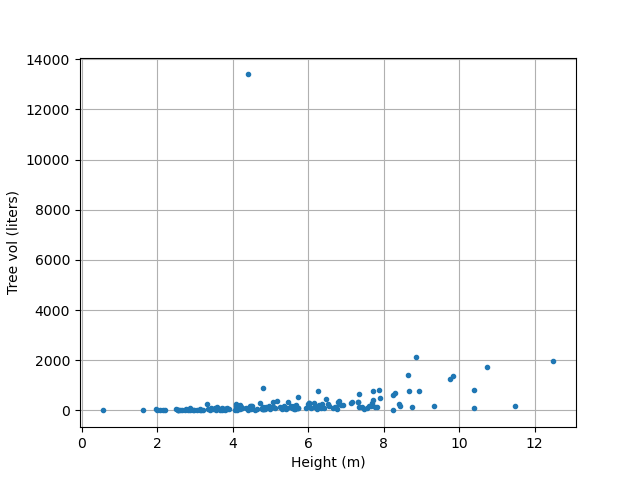

In [23]:
plt.figure()
plt.plot(df_clean['HT'], br, linestyle='', marker='.')
plt.grid('on')

plt.xlabel('Height (m)')
plt.ylabel('Tree vol (liters)')

In [24]:
df_clean[br>4000]

,DBH,HT,spp_eq,equ
348,300.484533,4.4,QUERCUS,OakWoodland_Chojnacky


In [25]:
wt.ldata.df.loc[348]

Plot                                                   3304
Tree Number                                             1.0
level_2                                                   1
DBH                                 118.30099706988126 inch
Quadrant                                                 SE
Species                                    Mexican Blue Oak
spp                                                    QUOB
DBH/DRC calculated                               118.300997
DBH/DRC                                                 DRC
dbh                                 118.30099706988126 inch
Unnamed: 8                                              0.0
DBH/DRC Circumfrence (cm)                             944.0
Height                                            4.4 meter
Base reading                                          -58.0
Top Reading                                            -3.0
Crown Class                                               I
Lowest Canopy Height                    

Zito investigated this. The original plot sheet has the circumference as 94 cm, not as 944 cm. I'll correct below.

In [26]:
dbh_cm = 94/np.pi
dbh_in = dbh_cm / 2.54

wt.ldata.df.loc[348, 'DBH'] = dbh_in
wt.ldata.df.loc[348, 'DBH/DRC Circumfrence (cm)'] = 94

Great, now one last check to make sure we're not missing anything.

Text(0, 0.5, 'Tree vol (liters)')

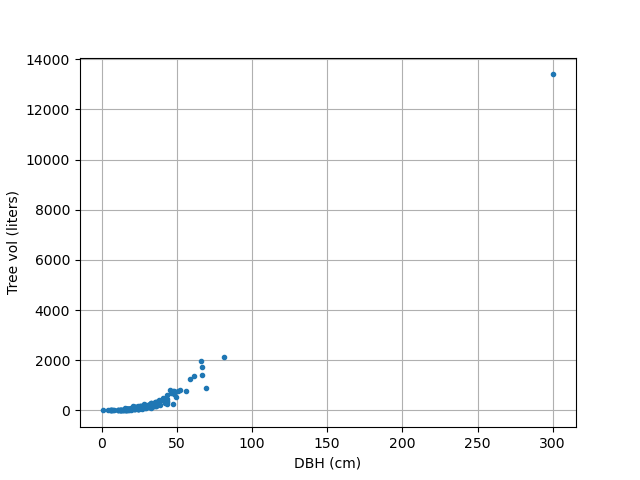

In [27]:
plt.figure()
plt.plot(df_clean['DBH'], br, linestyle='', marker='.')

plt.grid('on')
plt.xlabel('DBH (cm)')
plt.ylabel('Tree vol (liters)')

That's the one we fixed just above. Let's look at the main dataframe that I edited to ensure the change is in there. But to do that, we'll need to recalculate the biomass.

In [28]:
wt.calc_biomass('total')

172: RuntimeWarning: invalid value encountered in log10
172: RuntimeWarning: invalid value encountered in log10


Text(0, 0.5, 'Tree weight (kg)')

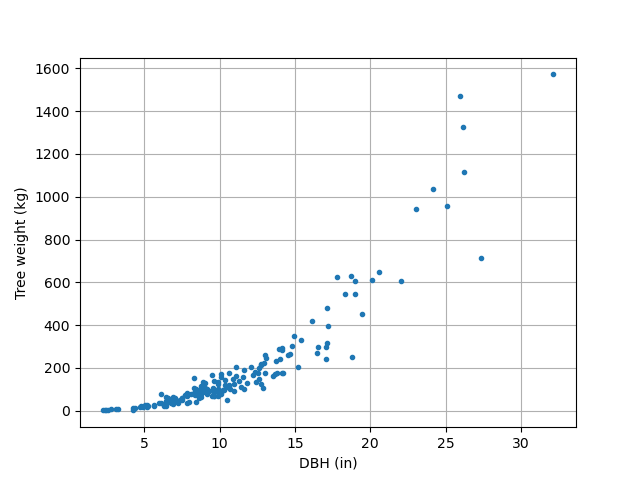

In [29]:
plt.figure()
dbh =  wt.ldata.df.loc[df_clean.index, ['DBH']].pint.dequantify()
tot_wt = wt.ldata.df.loc[df_clean.index, ['total_wt']].pint.dequantify()
plt.plot(dbh, tot_wt, linestyle='', marker='.')

plt.grid('on')
plt.xlabel('DBH (in)')
plt.ylabel('Tree weight (kg)')

That's the same one we just corrected via the height graph. All good here.

## Searching for problem values
### Negative biomass

In [30]:
wtless = (wt.ldata.df.total_wt <= 0) | (wt.ldata.df.foliage_wt <= 0)| (wt.ldata.df.avl_canfuel_wt <= 0)
wt.ldata.df.loc[wtless, ['DBH', 'Height', 'Species', 'equ', 'total_wt', 'foliage_wt', 'avl_canfuel_wt']]

,DBH,Height,Species,equ,total_wt,foliage_wt,avl_canfuel_wt
3,10.526784,2.028,SW White Pine,BCtimber_Standish,0.0,0.0,0.0
394,14.912943,2.625,Ponderosa Pine,BCtimber_Standish,-20.042006,54.555283,55.09468


Text(0, 0.5, 'Total Biomass (kg)')

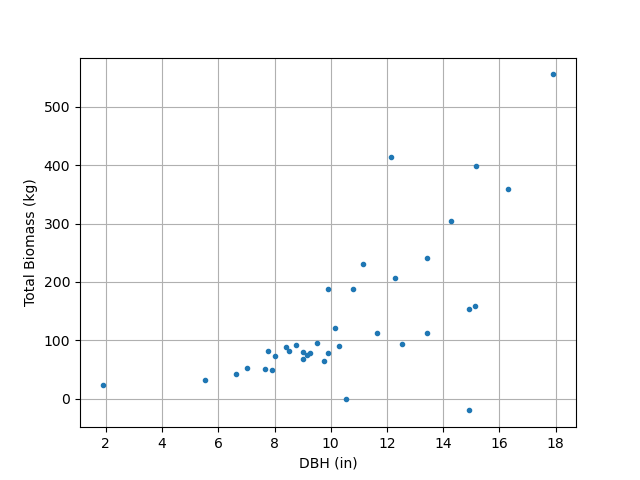

In [31]:
eq = wt.ldata.df.equ == 'BCtimber_Standish'
# pint units really get in the way here
df = wt.ldata.df.loc[eq, ['DBH', 'total_wt', 'Height']].pint.dequantify()

plt.figure()
plt.plot(df.DBH, df.total_wt, linestyle='', marker='.')
plt.grid('on')
plt.xlabel('DBH (in)')
plt.ylabel('Total Biomass (kg)')

That's really strange that such large diameter trees have such low biomass. It especially doesn't track with the overall pattern of increasing weight with increasing DBH.

Text(0, 0.5, 'Total Biomass (kg)')

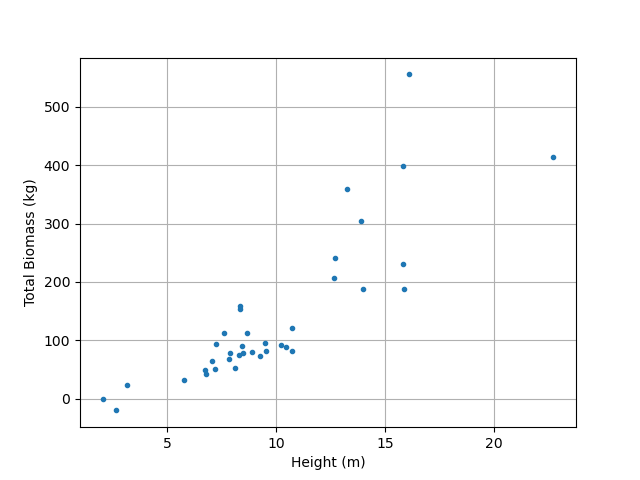

In [32]:
plt.figure()
plt.plot(df.Height, df.total_wt, linestyle='', marker='.')
plt.grid('on')

plt.xlabel('Height (m)')
plt.ylabel('Total Biomass (kg)')

Text(0, 0.5, 'Height (ft)')

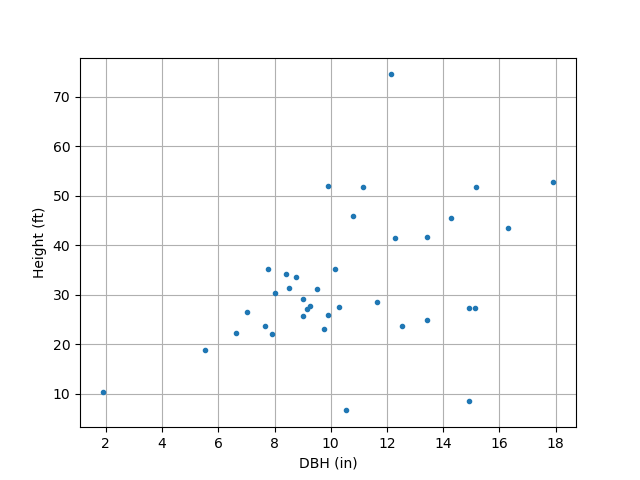

In [33]:
plt.figure()
plt.plot(df.DBH, df.Height*3.28084, linestyle='', marker='.')
plt.grid('on')

plt.xlabel('DBH (in)')
plt.ylabel('Height (ft)')

Those tiny heights seem to be dictating the 0 and negative weights, let's double check the raw data and see if there is some sort of error.

In [34]:
pd.options.display.max_columns = 50

In [35]:
wt.ldata.df[wtless]

,Plot,Tree Number,level_2,DBH,Quadrant,Species,spp,DBH/DRC calculated,DBH/DRC,dbh,Unnamed: 8,DBH/DRC Circumfrence (cm),Height,Base reading,Top Reading,Crown Class,Lowest Canopy Height,Lowest Canopy Height Reading,Tree Condition,Distance (M),Stems,spp_eq,equ,total_wt,foliage_wt,avl_canfuel_wt
3,101,4.0,1,10.526784,NW,SW White Pine,PIST3,10.526784,NaN,10.52678363757418 inch,0.0,84.0,2.028,-54.0,50.0,D,0.4485,-31.0,1.0,1.95,NaN,PIMO,BCtimber_Standish,0.0,0.0,0.0
394,3305,26.0,1,14.912943,SW,Ponderosa Pine,PIPO,14.912943,NaN,14.912943486563421 inch,0.0,119.0,2.625,-57.0,-15.0,NaN,3.5625,NaN,3.0,6.25,NaN,PIPO,BCtimber_Standish,-20.042006,54.555283,55.09468


The southwest white pine I really can't figure out. It's just so short for that diameter. But the ponderosa is dead, so it must be a dead candlestick. This requires a broader look at how to handle dead trees.

### Handling dead trees
After talking with Zito, his interpretation of class 3 was that it should have no needles. So all of the class 3's should be without foliage. 
Let's look at all of the dead (tree condition 3) trees and make sure everything makes sense.

In [88]:
dead = wt.ldata.df['Tree Condition'] == 3

wt.ldata.df[dead].sort_values('total_wt')

,Plot,Tree Number,level_2,DBH,Quadrant,Species,spp,DBH/DRC calculated,DBH/DRC,dbh,Unnamed: 8,DBH/DRC Circumfrence (cm),Height,Base reading,Top Reading,Crown Class,Lowest Canopy Height,Lowest Canopy Height Reading,Tree Condition,Distance (M),Stems,spp_eq,equ,total_wt,foliage_wt,avl_canfuel_wt
394,3305,26.0,1,14.912943,SW,Ponderosa Pine,PIPO,14.912943,NaN,14.912943486563421 inch,0.000000,119.0,2.625,-57.0,-15.0,NaN,3.5625,NaN,3.0,6.25,NaN,PIPO,BCtimber_Standish,-74.597289,0.0,0.539397
221,1055,24.0,1,2.005102,SE,Border Pinyon,PIDI3,2.005102,DRC,2.005101645252225 inch,0.000000,16.0,1.91,-15.0,5.0,S,1.4325,NaN,3.0,9.55,NaN,PIED,PJ_Grier,0.830378,0.0,0.240806
405,3305,37.0,1,2.381058,SW,Silver Leaf Oak,QUHY,2.381058,DRC,2.381058203737017 inch,0.000000,19.0,1.62,-72.0,-27.0,S,2.592,NaN,3.0,3.60,NaN,QUERCUS,OakWoodland_Chojnacky,0.854139,0.0,0.291489
59,358,6.0,1,2.85385,NE,Border Pinyon,PIDI3,1.629145,DBH,2.853850191744825 inch,1.224705,13.0,2.9835,-50.0,1.0,S,2.925,NaN,3.0,5.85,NaN,PIED,PJ_Grier,3.151346,0.0,0.503207
298,3301,6.0,1,4.38616,SW,Pinyon,PIED,4.386160,DBH,4.386159848989242 inch,0.000000,35.0,4.1205,-20.0,21.0,I,2.01,NaN,3.0,10.05,NaN,PIED,PJ_Grier,12.259495,0.0,1.234466
94,358,41.0,1,6.431489,NW,Mexican Blue Oak,QUOB,4.636798,DBH,6.4314893689901655 inch,1.794692,37.0,2.205,-61.0,-12.0,S,2.745,NaN,3.0,4.50,NaN,QUERCUS,OakWoodland_Chojnacky,20.61863,0.0,4.95148
48,308,1.0,1,5.51403,SW,Chihuahuan Pine,PILE,5.514030,NaN,5.514029524443618 inch,0.000000,44.0,5.746,-17.0,51.0,I,1.859,5.0,3.0,8.45,NaN,PIPO,BCtimber_Standish,24.762404,0.0,0.198415
220,1055,23.0,1,7.737885,SE,Alligator Juniper,JUDE2,5.639348,DBH,7.737884617487071 inch,2.098536,45.0,4.347,-16.0,26.0,S,1.656,NaN,3.0,10.35,NaN,JUMO,PJ_Grier,25.786434,0.0,1.711378
64,358,11.0,1,5.888374,NE,Border Pinyon,PIDI3,4.386160,DBH,5.888373972314304 inch,1.502214,35.0,4.982,-43.0,10.0,C,4.042,NaN,3.0,9.40,NaN,PIED,PJ_Grier,28.953595,0.0,2.283269
336,3303,12.0,1,7.895088,SE,Ponderosa Pine,PIPO,7.895088,NaN,7.895087728180634 inch,0.000000,63.0,6.716,-38.0,8.0,I,5.548,NaN,3.0,14.60,NaN,PIPO,BCtimber_Standish,33.863077,0.0,0.246601


Since Zito only assigned tree condition 3 when there were no needles, we should subtract the foliage biomass for all of these trees. That would leave all of the small branches on, which in the case of our candlestick discussed above, would be an overestimation. But it does match the field methods pretty well. And it would have a major impact on the available canopy fuel, which is key.

wt.ldata.df.loc[dead, 'total_wt'] -= wt.ldata.df.loc[dead, 'foliage_wt']
wt.ldata.df.loc[dead, 'avl_canfuel_wt'] -= wt.ldata.df.loc[dead, 'foliage_wt']
wt.ldata.df.loc[dead, 'foliage_wt'] = 0
wt.ldata.df[dead].sort_values('spp')

In [90]:
wtless = (wt.ldata.df.total_wt <= 0) | (wt.ldata.df.avl_canfuel_wt <= 0)
wt.ldata.df[wtless]

,Plot,Tree Number,level_2,DBH,Quadrant,Species,spp,DBH/DRC calculated,DBH/DRC,dbh,Unnamed: 8,DBH/DRC Circumfrence (cm),Height,Base reading,Top Reading,Crown Class,Lowest Canopy Height,Lowest Canopy Height Reading,Tree Condition,Distance (M),Stems,spp_eq,equ,total_wt,foliage_wt,avl_canfuel_wt
3,101,4.0,1,10.526784,NW,SW White Pine,PIST3,10.526784,NaN,10.52678363757418 inch,0.0,84.0,2.028,-54.0,50.0,D,0.4485,-31.0,1.0,1.95,NaN,PIMO,BCtimber_Standish,0.0,0.0,0.0
394,3305,26.0,1,14.912943,SW,Ponderosa Pine,PIPO,14.912943,NaN,14.912943486563421 inch,0.0,119.0,2.625,-57.0,-15.0,NaN,3.5625,NaN,3.0,6.25,NaN,PIPO,BCtimber_Standish,-74.597289,0.0,0.539397


That still doesn't fix our negative weight problem. Actually, it makes it worse... OK, let's check on the volume measurement.

In [95]:
# first get a clean df with the right units and column names
df_slice = wt.ldata.df[wt.ldata.df.equ =='BCtimber_Standish']
bc_cls = getattr(allometry, 'BCtimber_Standish')
df_clean = wt.get_clean_df(df_slice, bc_cls.required_columns, bc_cls.units )

bc = allometry.BCtimber_Standish(df_clean)

In [119]:
v = bc.calc_vol()

bc.trees[v<=0.0]

,HT,DBH,spp_eq,equ
3,2.028,0.26738,PIMO,BCtimber_Standish


In [121]:
v[v<=0.0]

array([0.])

So, a volume of 0. Let's see about the other terms in the biomass equation.

In [98]:
pimo = bc.trees[v<=0]
-10.3 + 334.2*v[v<=0] + 1628.2*pimo.DBH**2

3    106.103644
Name: DBH, dtype: Float64

In [99]:
pimo.DBH**2

3    0.071492
Name: DBH, dtype: Float64

Got it!! 

That equation should provide 106kg of tree for that short but stout tree.

The species_eq.yaml provides:

```yaml
PIST3:
  name: SW White Pine
  equ: BCtimber_Standish
  spp_eq: PIMO
```

But the coefficients dictionary provides:
```python
...
'PIMO3':[-0.5, 6.7, 61.7, 0, 0, 0, 0, 0],
...
```

I simply corrected the yaml. Now it should produces a modest weight.

In [122]:
# first get a clean df with the right units and column names
wt.add_equ_column()

df_slice = wt.ldata.df[wt.ldata.df.equ =='BCtimber_Standish']
bc_cls = getattr(allometry, 'BCtimber_Standish')
df_clean = wt.get_clean_df(df_slice, bc_cls.required_columns, bc_cls.units )

bc = allometry.BCtimber_Standish(df_clean)

In [123]:
v = bc.calc_vol()

bc.trees[v<=0.0]

,HT,DBH,spp_eq,equ


In [193]:
t = bc.calc_tot_tree_weight()
bc.trees[t<=0]

,HT,DBH,spp_eq,equ


In [194]:
t = bc.calc_foliar_weight()
bc.trees[t<=0]

,HT,DBH,spp_eq,equ


In [195]:
t[bc.trees.spp_eq=='PIMO3']

array([41.83448308])

Fixed! Now let's jump into that strange pondo.

In [126]:
tot = bc.calc_tot_tree_weight()
bc.trees[tot<0]

,HT,DBH,spp_eq,equ
394,2.625,0.378789,PIPO,BCtimber_Standish


In [127]:
pipo = bc.trees[tot<0]

23.9 + 733.1*v[tot<0] -851.9*pipo.DBH**2

394   -20.042006
Name: DBH, dtype: Float64

well, the equation checks out. There's such a large negative coefficient in front of DBH, and the DBH is large relative to the volume because it is short and stubby... I'll take a quick look at the components.

In [108]:
pipo.DBH**2

394    0.143481
Name: DBH, dtype: Float64

In [105]:
v[tot<0]

array([0.10679225])

This tree seems like a candle stick with the top broken off. Let's see what the volume would be if it were just a cylinder.

In [107]:
pipo.HT * (np.pi * (pipo.DBH/2)**2)

394    0.29581
dtype: Float64

In [109]:
23.9 + 733.1*0.29581 -851.9*pipo.DBH**2

394    118.526908
Name: DBH, dtype: Float64

In [186]:
# revised m3 * specificGravity * 1000m3/kg
0.29581 * 0.4*1000

118.32400000000001

The volume equation is assuming a natural grown tree which tapers to a point. So it under-estimates volume relative to that of a cylinder, which would be correct, if this weren't pretty clearly a tree where the top had snapped off. 

When I recalculated the volume as a cylinder and ran it back through the equation, it got almost the exact same kg of weight as a cylinder *the density of wood.

So we need a criteria where we can pick out and adjust the volume for this sort of case. Let's look at the relationship between height and dbh and volume and dbh for starters.

3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.


Text(0, 0.5, 'Height / DBH')

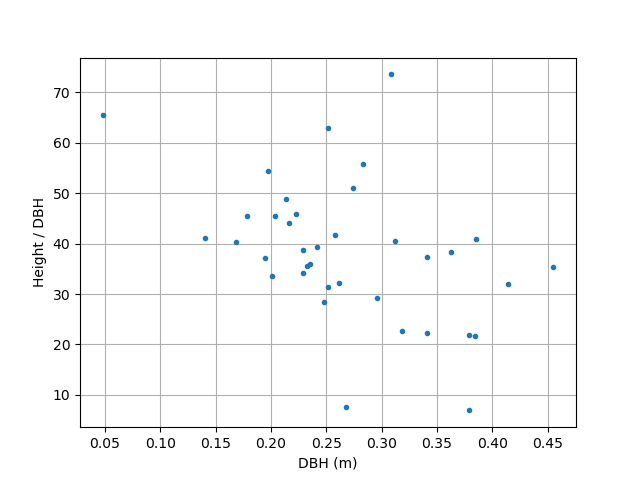

In [115]:
ratio =  bc.trees.HT/bc.trees.DBH

plt.figure()
plt.plot(bc.trees.DBH, ratio, linestyle='', marker='.')

plt.grid('on')
plt.xlabel('DBH (m)')
plt.ylabel('Height / DBH')

In [116]:
ratio[ratio<10]

3      7.584702
394    6.929984
dtype: Float64

HT/DBH < 8 seems promising...but the problem is in the volume...Let's take a look at that.

Text(0, 0.5, 'TaperedVol / CylVol')

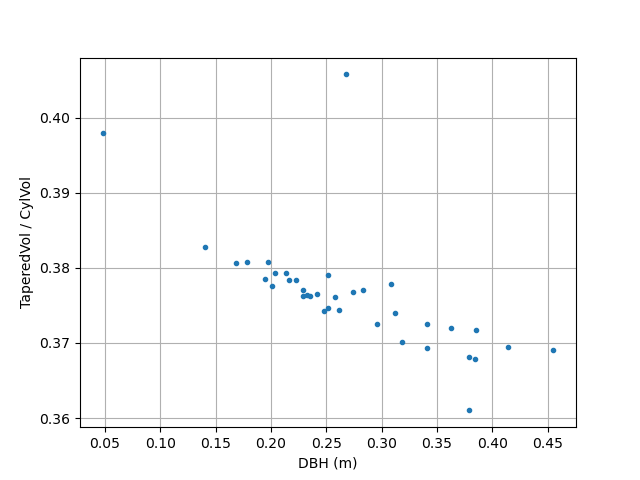

In [171]:
cyl = bc.trees.HT * (np.pi * (bc.trees.DBH/2)**2)
ratio =  v/cyl

plt.figure()
plt.plot(bc.trees.DBH, ratio, linestyle='', marker='.')

plt.grid('on')
plt.xlabel('DBH (m)')
plt.ylabel('TaperedVol / CylVol')

In [169]:
ratio[ratio<0.37]

4      0.368063
33     0.369302
41     0.367868
135    0.369451
212    0.369056
394    0.361016
dtype: Float64

That stubby PIPO is a clear outlier. Maybe that will work... I want to double check that other stubby western white pine.

In [170]:
bc.trees[ratio>0.4]

,HT,DBH,spp_eq,equ
3,2.028,0.26738,PIMO3,BCtimber_Standish


In [187]:
v[ratio>0.4]

array([0.04620609])

In [188]:
cyl[ratio>0.4]

3    0.113872
dtype: Float64

That is a shockingly small volume for that 10" western white pine... Can I just use small volume as a filter.

Text(0, 0.5, 'TaperedVol / CylVol')

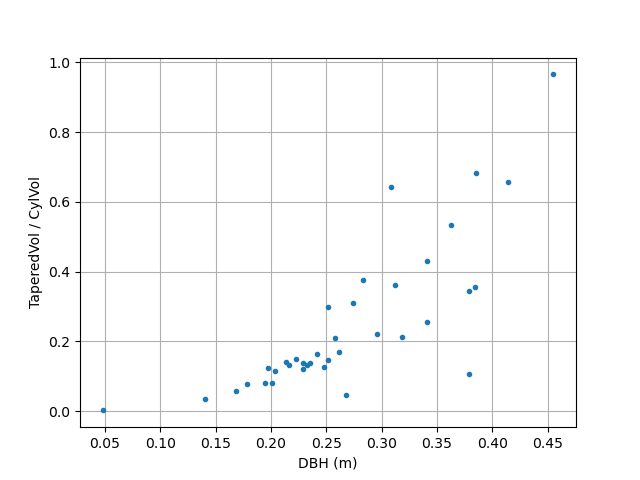

In [190]:
plt.figure()
plt.plot(bc.trees.DBH, v, linestyle='', marker='.')

plt.grid('on')
plt.xlabel('DBH (m)')
plt.ylabel('TaperedVol / CylVol')

In [174]:
v[ratio<0.37]

array([0.34479721, 0.25603266, 0.35564116, 0.65734458, 0.96581549,
       0.10679225])

The ratio of height to dbh seems really sound, both mechanistically and empirically. I'm a little more nervous about the ratio of volume to that of a cylinder. I know this will work for this particular problem, but I'm just not sure how well it will hold up. But I need some criteria in addition to the ht2dbh ratio to keep it from altering the western white, which gives numbers in the same ballpark as our pondo without modification...

I could place the check only after weight has been calculated, but then it would have to run for every weight calculation...and it would have to rerun the volume math and the species math...

Here goes nothing...

In [199]:

stubby = (bc.trees['HT'] / bc.trees['DBH']) < 8

cyl = bc.trees['HT'] * np.pi * (bc.trees['DBH']/2)**2
undervol = (bc.vol/cyl) < 0.365

short = bc.trees['HT'] < 4

broken_snag = stubby & short & undervol

bc.trees[broken_snag]

,HT,DBH,spp_eq,equ
394,2.625,0.378789,PIPO,BCtimber_Standish


In [200]:
bc.vol[broken_snag] = cyl[broken_snag]

In [201]:
t = bc.calc_tot_tree_weight()
bc.trees[t<0]

,HT,DBH,spp_eq,equ


In [202]:
t[bc.trees.index==394]

array([118.52716549])

In [203]:
 bc.calc_foliar_weight()[bc.trees.index==394]

array([50.98284104])

Looks like that worked. Plus, because it's dead, the 51 kg will be subtracted from both the total and the 

## Checking on new equations
Now that the tree species have been accounted for, we're trying to add in some of the large shrub species as canopy fuel.

### Mesquite

In [220]:
del sys.modules['calc_biomass']
del sys.modules['calc_biomass.allometry']
del sys.modules['calc_biomass.manage_data']

from calc_biomass import allometry
from calc_biomass import manage_data

In [221]:
# first get a clean df with the right units and column names
wt.add_equ_column()

df_slice = wt.ldata.df[wt.ldata.df.equ =='Mesquite_McClaren']
m_cls = getattr(allometry, 'Mesquite_McClaren')
df_clean = wt.get_clean_df(df_slice, m_cls.required_columns, m_cls.units )

m = allometry.Mesquite_McClaren(df_clean)

In [223]:
t = m.calc_tot_tree_weight()
a = m.calc_avl_canfuel()

In [225]:
m.trees[t<=0]

,DBH,spp_eq,equ


In [226]:
m.trees[a<=0]

,DBH,spp_eq,equ


Text(0, 0.5, 'Total Biomass (kg)')

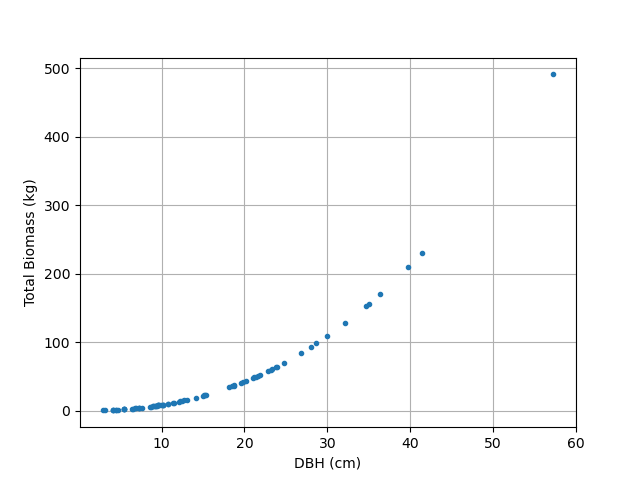

In [227]:
plt.figure()
plt.plot(m.trees.DBH, t, linestyle='', marker='.')

plt.grid('on')
plt.xlabel('DBH (cm)')
plt.ylabel('Total Biomass (kg)')

Looks good to me.

## CBH Corrections


In [229]:
no_cbh = wt.ldata.df['Lowest Canopy Height Reading'].isna()
wt.ldata.df[no_cbh]

,Plot,Tree Number,level_2,DBH,Quadrant,Species,spp,DBH/DRC calculated,DBH/DRC,dbh,Unnamed: 8,DBH/DRC Circumfrence (cm),Height,Base reading,Top Reading,Crown Class,Lowest Canopy Height,Lowest Canopy Height Reading,Tree Condition,Distance (M),Stems,spp_eq,equ,total_wt,foliage_wt,avl_canfuel_wt
4,101,5.0,1,14.912943,NW,Ponderosa Pine,PIPO,14.912943,NaN,14.912943486563421 inch,0.000000,119.0,8.313,-17.0,34.0,NaN,2.771,NaN,3.0,16.30,NaN,PIPO,BCtimber_Standish,104.382441,0.0,0.479895
9,105,2.0,1,10.150827,NW,Border Pinyon,PIDI3,10.150827,DRC,10.150827079089389 inch,0.000000,81.0,7.26,-48.0,18.0,I,5.28,NaN,3.0,11.00,NaN,PIED,PJ_Grier,131.679584,0.0,7.118389
39,307,7.0,1,32.317459,SW,Alligator Juniper,JUDE2,25.314408,DBH,32.3174591294748 inch,7.003051,202.0,6.12,-10.0,41.0,NaN,1.2,NaN,3.0,12.00,NaN,JUMO,PJ_Grier,461.297967,0.0,22.016189
57,358,4.0,1,7.816854,NE,Mexican Blue Oak,QUOB,5.764667,DBH,7.816854093291473 inch,2.052187,46.0,2.5885,-19.0,12.0,S,1.5865,NaN,3.0,8.35,NaN,QUERCUS,OakWoodland_Chojnacky,34.786903,0.0,7.730608
59,358,6.0,1,2.85385,NE,Border Pinyon,PIDI3,1.629145,DBH,2.853850191744825 inch,1.224705,13.0,2.9835,-50.0,1.0,S,2.925,NaN,3.0,5.85,NaN,PIED,PJ_Grier,3.151346,0.0,0.503207
64,358,11.0,1,5.888374,NE,Border Pinyon,PIDI3,4.386160,DBH,5.888373972314304 inch,1.502214,35.0,4.982,-43.0,10.0,C,4.042,NaN,3.0,9.40,NaN,PIED,PJ_Grier,28.953595,0.0,2.283269
77,358,24.0,1,7.895088,SW,Border Pinyon,PIDI3,7.895088,DRC,7.895087728180634 inch,0.000000,63.0,5.478,-44.0,22.0,C,3.652,NaN,3.0,8.30,NaN,PIED,PJ_Grier,66.03178,0.0,4.211997
94,358,41.0,1,6.431489,NW,Mexican Blue Oak,QUOB,4.636798,DBH,6.4314893689901655 inch,1.794692,37.0,2.205,-61.0,-12.0,S,2.745,NaN,3.0,4.50,NaN,QUERCUS,OakWoodland_Chojnacky,20.61863,0.0,4.95148
173,824,5.0,1,8.521682,SE,2 Needle Pinyon,PIED,8.521682,DRC,8.521681992321955 inch,0.000000,68.0,5.27,-41.0,21.0,C,3.485,NaN,3.0,8.50,NaN,PIED,PJ_Grier,81.550284,0.0,4.94019
174,824,6.0,1,7.932091,SE,2 Needle Pinyon,PIED,6.265943,DBH,7.93209055952621 inch,1.666148,50.0,7.828,1.0,104.0,S,-0.076,NaN,3.0,7.60,NaN,PIED,PJ_Grier,66.893156,0.0,4.253321


Many of those still list a lowest canopy height, so I'll have to take care of that. But most of those are dead anyhow.

In [230]:
dead = wt.ldata.df['Tree Condition']==3
wt.ldata.df[~dead&no_cbh]

,Plot,Tree Number,level_2,DBH,Quadrant,Species,spp,DBH/DRC calculated,DBH/DRC,dbh,Unnamed: 8,DBH/DRC Circumfrence (cm),Height,Base reading,Top Reading,Crown Class,Lowest Canopy Height,Lowest Canopy Height Reading,Tree Condition,Distance (M),Stems,spp_eq,equ,total_wt,foliage_wt,avl_canfuel_wt
482,6016,1.0,1,1.12787,SE,Acacia,SEGR10,1.127870,NaN,1.1278696754543764 inch,0.0,9.0,NaN,NaN,NaN,S,0.0,NaN,2.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN
485,6016,4.0,1,0.877232,NE,Acacia,SEGR10,0.877232,NaN,0.8772319697978483 inch,0.0,7.0,NaN,NaN,NaN,I,0.0,NaN,2.0,NaN,7.0,NaN,NaN,NaN,NaN,NaN
486,6016,5.0,1,1.253189,NE,Acacia,SEGR10,1.253189,NaN,1.2531885282826405 inch,0.0,10.0,NaN,NaN,NaN,I,0.0,NaN,2.0,NaN,17.0,NaN,NaN,NaN,NaN,NaN
489,6016,8.0,1,0.877232,NE,Acacia,SEGR10,0.877232,NaN,0.8772319697978483 inch,0.0,7.0,NaN,NaN,NaN,I,0.0,NaN,2.0,NaN,5.0,NaN,NaN,NaN,NaN,NaN
492,6016,11.0,1,1.12787,SW,Acacia,SEGR10,1.127870,NaN,1.1278696754543764 inch,0.0,9.0,NaN,NaN,NaN,I,0.0,NaN,2.0,NaN,7.0,NaN,NaN,NaN,NaN,NaN
493,6016,12.0,1,1.002551,SW,Acacia,SEGR10,1.002551,NaN,1.0025508226261124 inch,0.0,8.0,NaN,NaN,NaN,S,0.0,NaN,2.0,NaN,12.0,NaN,NaN,NaN,NaN,NaN
494,6016,13.0,1,1.12787,SW,Acacia,SEGR10,1.127870,NaN,1.1278696754543764 inch,0.0,9.0,NaN,NaN,NaN,I,0.0,NaN,2.0,NaN,10.0,NaN,NaN,NaN,NaN,NaN
497,6016,16.0,1,0.877232,NE,Creosote,LATR2,0.877232,NaN,0.8772319697978483 inch,0.0,7.0,2.1,NaN,NaN,S,0.0,NaN,2.0,NaN,12.0,NaN,NaN,NaN,NaN,NaN
500,6016,19.0,1,1.12787,NW,Creosote,LATR2,1.127870,NaN,1.1278696754543764 inch,0.0,9.0,1.95,NaN,NaN,S,0.0,NaN,1.0,NaN,11.0,NaN,NaN,NaN,NaN,NaN
502,6016,21.0,1,1.503826,SE,Creosote,LATR2,1.503826,NaN,1.5038262339391684 inch,0.0,12.0,1.97,NaN,NaN,S,0.0,NaN,2.0,NaN,11.0,NaN,NaN,NaN,NaN,NaN


OK, so we're missing some CBH data for a few creosote and acacia. No biggy.

In [231]:
no_cbh = wt.ldata.df['Lowest Canopy Height Reading'].isna()
wt.ldata.df.loc[no_cbh, 'Lowest Canopy Height'] = np.nan